In [84]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

nltk.download('stopwords')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [85]:
# Load files
neg_train = pd.read_csv("train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
pos_train = pd.read_csv("train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)

# Add labels
neg_train['label'] = 0
pos_train['label'] = 1

# Drop the first column (which contains 'neg' or 'pos' string) and rename the second column (which contains the text)
neg_train = neg_train.drop(columns=[0]).rename(columns={1: 'text'})
pos_train = pos_train.drop(columns=[0]).rename(columns={1: 'text'})

# Merge
df = pd.concat([neg_train, pos_train], axis=0).reset_index(drop=True)


In [86]:
df.head()

,text,label
0,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...,0
1,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...,0
2,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...,0
3,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...,0
4,الدودو جايه تكمل علي 💔,0


In [87]:
arabic_stopwords = set(stopwords.words('arabic'))
stemmer = ISRIStemmer()

def preprocess_arabic(text):

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions & hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", "", text)

    # Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)

    # Remove Tashkeel
    text = re.sub(r"[ًٌٍَُِّْ]", "", text)

    # Remove Tatweel
    text = re.sub(r"ـ", "", text)

    # Tokenization
    words = text.split()

    # Remove stopwords + stemming
    words = [stemmer.stem(w) for w in words if w not in arabic_stopwords]

    return " ".join(words)

In [88]:
# Apply Preprocessing
df['clean_text'] = df['text'].apply(preprocess_arabic)

In [89]:
df.head()

,text,label,clean_text
0,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...,0,عرف ان بتس كنو شوي شوي جيبو رسي اليوم زيد 😭
1,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...,0,وقع اذا جات دار بشف كمل حين احس احد نقص 💔
2,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...,0,كتب وقع نتج لقء هلل اهل تاق 👇 دخل سحب قيم ايف ...
3,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...,0,نعم ضاد حيي تضع قطره💧مضاد نسل علي كتر 🦠 فجر 💥 ...
4,الدودو جايه تكمل علي 💔,0,دودو جيه كمل علي 💔


In [90]:
# TF-IDF + N-Grams
vectorizer = TfidfVectorizer(
  ngram_range=(1,2),
  max_features=100000,
  sublinear_tf=True,
  min_df=5,
  max_df=0.9,
  use_idf=True,
  smooth_idf=True,
  norm='l2',
  encoding='utf-8',
  decode_error='ignore',
  analyzer='word',
  stop_words=None
)

x=vectorizer.fit_transform(df['clean_text'])
y=df['label']

In [91]:
# Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)


In [92]:
# Models -- Naive Bayes
nb_model=MultinomialNB()
nb_model.fit(x_train, y_train)

y_pred_nb=nb_model.predict(x_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7510767531750414
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      4503
           1       0.77      0.71      0.74      4552

    accuracy                           0.75      9055
   macro avg       0.75      0.75      0.75      9055
weighted avg       0.75      0.75      0.75      9055



In [93]:
#  Logistic Regression
param_grid={
    'C':[0.1,1,10]
}

lr= LogisticRegression(max_iter=1000)
grid=GridSearchCV(lr,param_grid,cv=3,n_jobs=-1)
grid.fit(x_train,y_train)

best_lr = grid.best_estimator_

y_pred_lr = best_lr.predict(x_test)

print("Best Params:", grid.best_params_)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Best Params: {'C': 10}
Logistic Regression Accuracy: 0.7634456101601326


In [94]:
# Evaluation --- Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.76      0.77      0.76      4503
           1       0.77      0.75      0.76      4552

    accuracy                           0.76      9055
   macro avg       0.76      0.76      0.76      9055
weighted avg       0.76      0.76      0.76      9055



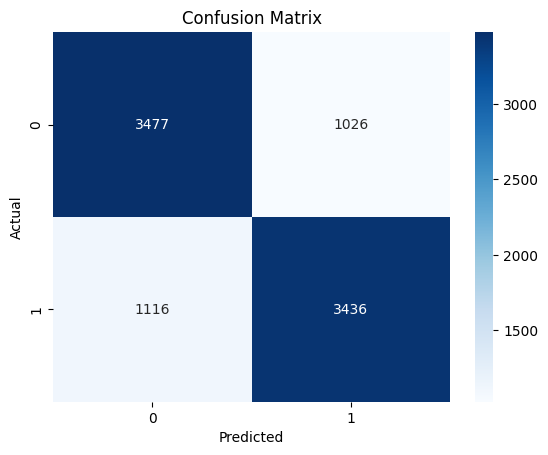

In [95]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [96]:
# Comparison
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Naive Bayes Accuracy: 0.7510767531750414
Logistic Regression Accuracy: 0.7634456101601326
